# Retail Sales Exploratory Data Analysis

## Project Objective

This project performs an exploratory data analysis of retail sales transactions using Python. The analysis examines sales trends, customer demographics, product categories, transaction quantities, revenue, and relationships between numerical variables.

The objective is to identify meaningful patterns and generate actionable business insights and recommendations that can support better retail decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [7]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Total missing values: 0


### Data Quality Observation

The dataset contains 1,000 records and 9 columns. There are no missing values in any of the columns, indicating that the dataset is complete for the variables used in this analysis.

In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
print("Number of unique Transaction IDs:", df["Transaction ID"].nunique())
print("Number of unique Customer IDs:", df["Customer ID"].nunique())
print("Product Categories:", df["Product Category"].unique())
print("Gender categories:", df["Gender"].unique())

Number of unique Transaction IDs: 1000
Number of unique Customer IDs: 1000
Product Categories: ['Beauty' 'Clothing' 'Electronics']
Gender categories: ['Male' 'Female']


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [12]:
print("Earliest transaction date:", df["Date"].min())
print("Latest transaction date:", df["Date"].max())

Earliest transaction date: 2023-01-01 00:00:00
Latest transaction date: 2024-01-01 00:00:00


In [13]:
numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]

df[numeric_columns].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


In [14]:
mean_values = df[numeric_columns].mean()

print("Mean:")
print(mean_values)

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


In [15]:
median_values = df[numeric_columns].median()

print("Median:")
print(median_values)

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [16]:
mode_values = df[numeric_columns].mode().iloc[0]

print("Mode:")
print(mode_values)

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [17]:
std_values = df[numeric_columns].std()

print("Standard Deviation:")
print(std_values)

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [18]:
descriptive_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

descriptive_summary

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


### Descriptive Statistics Observation

The descriptive statistics provide an overview of customer age, quantity purchased, unit prices, and transaction values. The average transaction amount is approximately ₦456, while transaction values vary considerably across customers. Price per Unit and Total Amount show relatively high variability, indicating that customers purchase products at different price points and transaction values.

In [19]:
total_revenue = df["Total Amount"].sum()

print(f"Total Revenue: ₦{total_revenue:,.2f}")

Total Revenue: ₦456,000.00


In [20]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 2514


In [21]:
average_transaction = df["Total Amount"].mean()

print(f"Average Transaction Value: ₦{average_transaction:,.2f}")


Average Transaction Value: ₦456.00


In [22]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

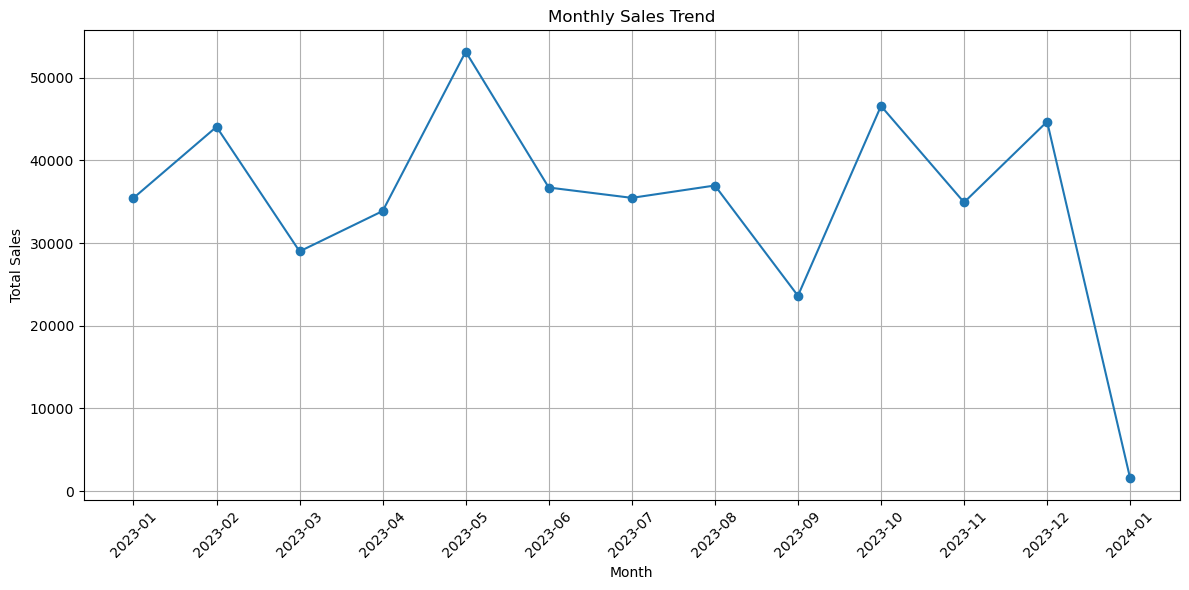

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Monthly Sales Observation

Monthly sales fluctuate throughout the period rather than following a consistently increasing or decreasing pattern. May 2023 recorded one of the strongest monthly sales performances, while September 2023 recorded a relatively low sales value. January 2024 should be interpreted cautiously because the dataset contains only a partial day for that month.

In [24]:
df["Quarter"] = df["Date"].dt.to_period("Q")

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

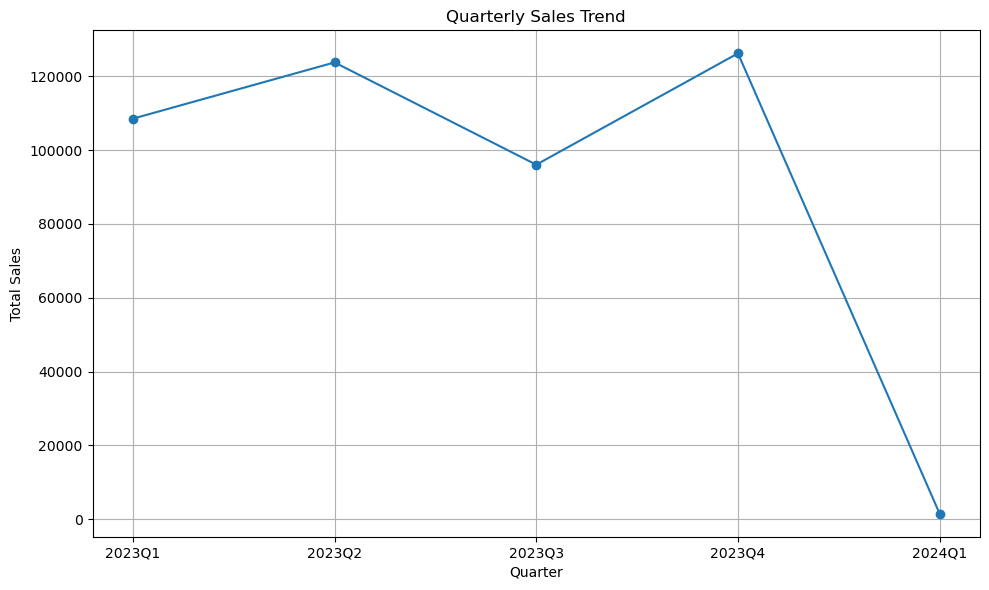

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()

plt.show()

### Quarterly Sales Observation

Quarterly sales show fluctuations across the observed period. The fourth quarter of 2023 recorded the highest complete-quarter sales, while the third quarter recorded comparatively lower sales. The 2024 Q1 value is not comparable with the full quarters because the dataset only contains a partial January 2024 record.

In [26]:
bins = [17, 24, 34, 44, 54, 64, 100]

labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["Age Group"].value_counts().sort_index()

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
65+        0
Name: count, dtype: int64

In [27]:
age_group_sales = df.groupby(
    "Age Group",
    observed=True
)["Total Amount"].sum()

age_group_sales

Age Group
18-24    74650
25-34    97090
35-44    96835
45-54    97235
55-64    90190
Name: Total Amount, dtype: int64

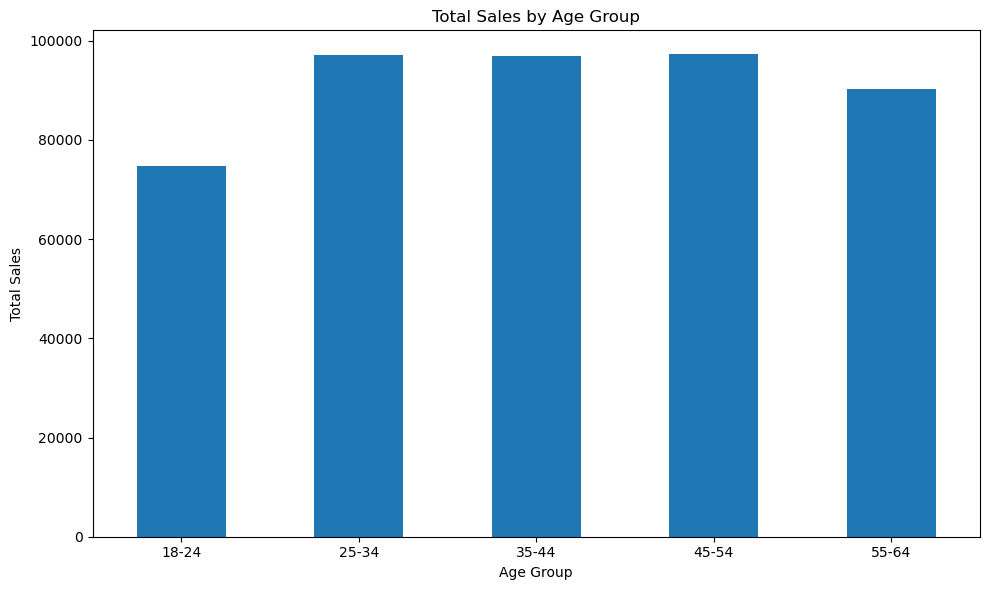

In [28]:
plt.figure(figsize=(10, 6))

age_group_sales.plot(kind="bar")

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Age Group Observation

Customers are distributed across several age groups, with the 45–54 age group accounting for a substantial number of transactions. Younger customers also demonstrate strong transaction values. This indicates that the business serves customers across multiple age segments rather than relying on a single age group.

In [29]:
gender_count = df["Gender"].value_counts()

gender_count

Gender
Female    510
Male      490
Name: count, dtype: int64

In [30]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

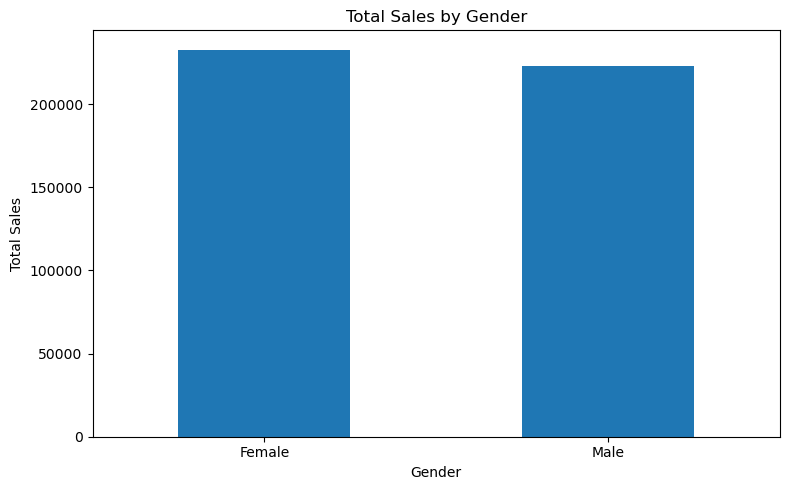

In [31]:
plt.figure(figsize=(8, 5))

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Gender Analysis Observation

Female customers account for slightly more transactions and total sales than male customers. However, the difference is relatively small, suggesting that both genders represent important customer segments. Marketing activities should therefore avoid focusing exclusively on one gender.

In [32]:
category_summary = df.groupby("Product Category").agg(
    Transactions=("Transaction ID", "count"),
    Quantity_Sold=("Quantity", "sum"),
    Revenue=("Total Amount", "sum"),
    Average_Transaction=("Total Amount", "mean")
)

category_summary

,Transactions,Quantity_Sold,Revenue,Average_Transaction
Product Category,,,,
Beauty,307,771,143515,467.475570
Clothing,351,894,155580,443.247863
Electronics,342,849,156905,458.786550


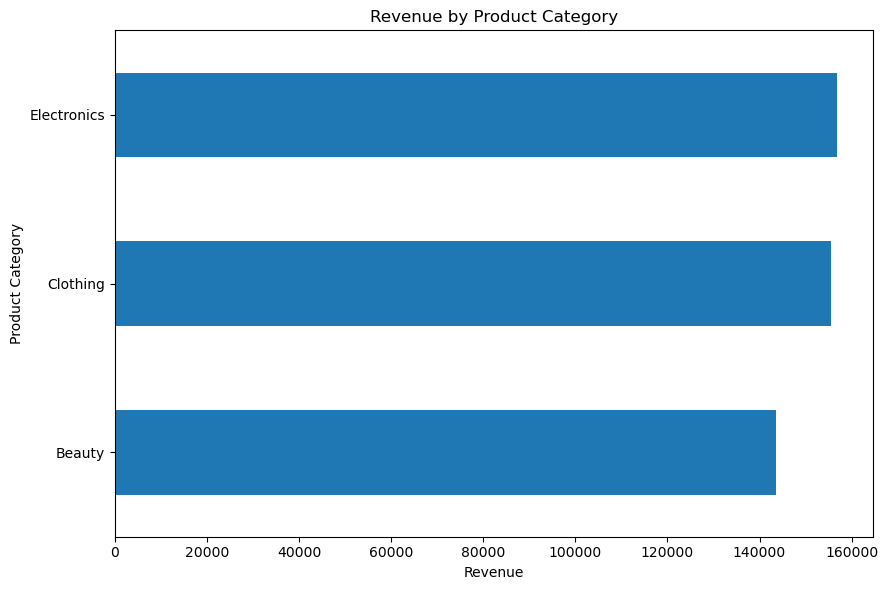

In [33]:
plt.figure(figsize=(9, 6))

category_summary["Revenue"].sort_values().plot(kind="barh")

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()

plt.show()

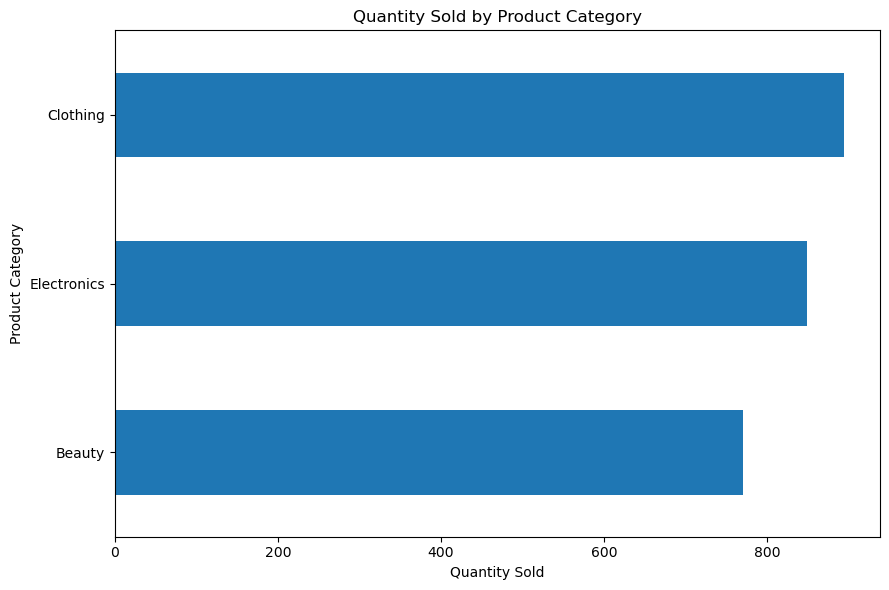

In [34]:
plt.figure(figsize=(9, 6))

category_summary["Quantity_Sold"].sort_values().plot(kind="barh")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()

plt.show()

### Product Category Observation

Electronics generates the highest total revenue among the product categories, while Clothing records the highest number of transactions and quantity sold. Beauty has a comparatively lower total revenue but maintains a strong average transaction value. This suggests that sales volume and revenue performance are not always driven by the same category.

In [35]:
correlation_data = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


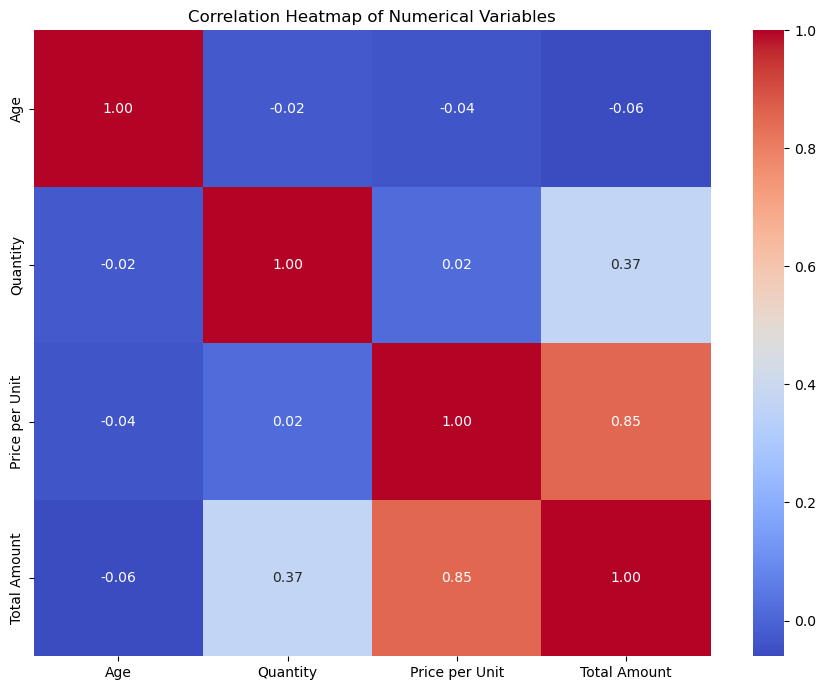

In [36]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()

plt.show()


### Correlation Observation

Price per Unit has a strong positive relationship with Total Amount because higher-priced products generally contribute more to transaction value. Quantity also has a moderate positive relationship with Total Amount, meaning that purchasing more units tends to increase transaction value. Age has very weak relationships with the other numerical variables, suggesting that customer age alone does not strongly determine transaction value or quantity purchased.

In [37]:
average_by_age = df.groupby(
    "Age Group",
    observed=True
)["Total Amount"].mean()

average_by_age

Age Group
18-24    501.006711
25-34    478.275862
35-44    467.801932
45-54    432.155556
55-64    417.546296
Name: Total Amount, dtype: float64

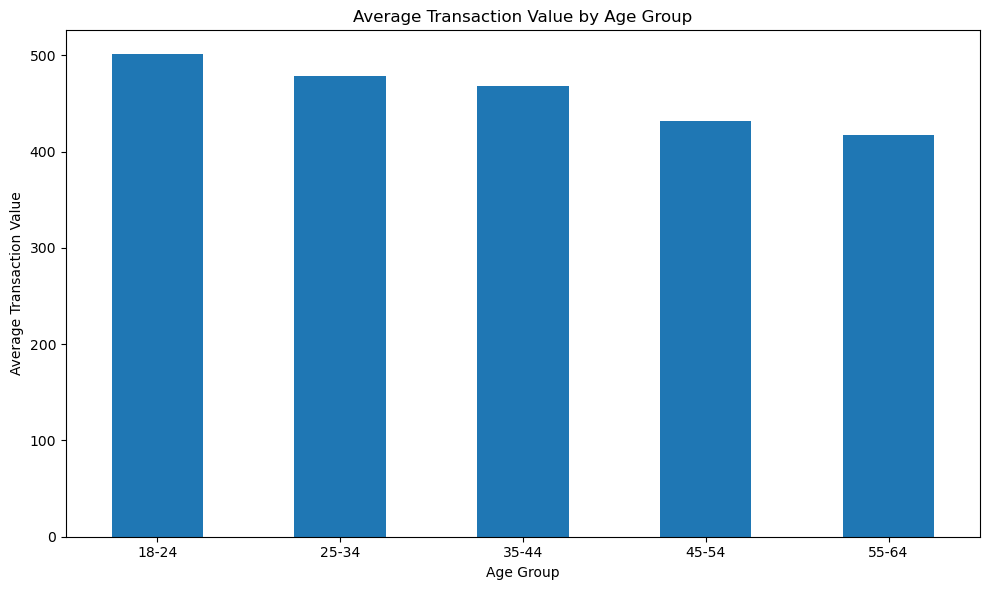

In [38]:
plt.figure(figsize=(10, 6))

average_by_age.plot(kind="bar")

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Additional Insight

The average transaction value generally decreases across the older age groups. Customers aged 18–24 have one of the highest average transaction values, while older age groups show comparatively lower average transaction values. This suggests that customer age may be useful for segmenting marketing campaigns, although age alone does not have a strong statistical correlation with total transaction value.

In [39]:
gender_summary = df.groupby("Gender").agg(
    Transactions=("Transaction ID", "count"),
    Quantity=("Quantity", "sum"),
    Revenue=("Total Amount", "sum"),
    Average_Transaction=("Total Amount", "mean")
)

gender_summary

,Transactions,Quantity,Revenue,Average_Transaction
Gender,,,,
Female,510,1298,232840,456.549020
Male,490,1216,223160,455.428571


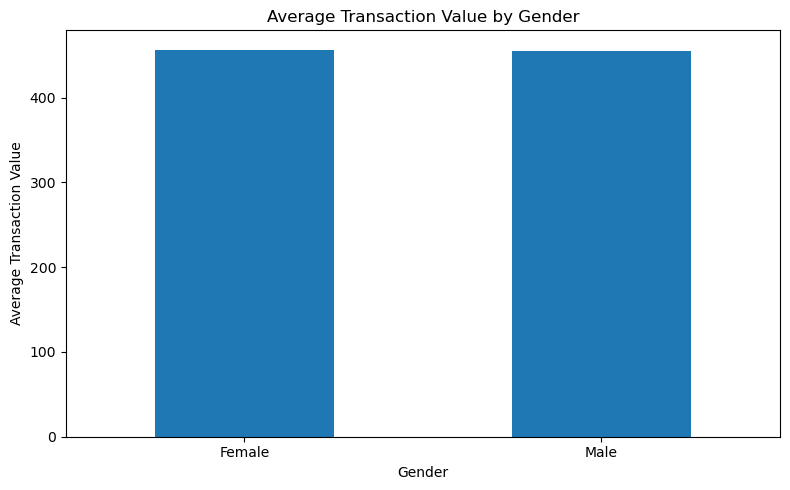

In [40]:
plt.figure(figsize=(8, 5))

gender_summary["Average_Transaction"].plot(kind="bar")

plt.title("Average Transaction Value by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [41]:
best_category = category_summary["Revenue"].idxmax()
best_category_revenue = category_summary["Revenue"].max()

print("Highest Revenue Category:", best_category)
print(f"Revenue: ₦{best_category_revenue:,.2f}")

Highest Revenue Category: Electronics
Revenue: ₦156,905.00


In [42]:
most_purchased_category = category_summary["Quantity_Sold"].idxmax()

print("Most Purchased Category:", most_purchased_category)

Most Purchased Category: Clothing


In [43]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Best Sales Month:", best_month)
print(f"Sales: ₦{best_month_sales:,.2f}")

Best Sales Month: 2023-05
Sales: ₦53,150.00


In [44]:
best_quarter = quarterly_sales.idxmax()
best_quarter_sales = quarterly_sales.max()

print("Best Quarter:", best_quarter)
print(f"Sales: ₦{best_quarter_sales:,.2f}")

Best Quarter: 2023Q4
Sales: ₦126,190.00


In [45]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Transactions",
        "Total Revenue",
        "Total Quantity Sold",
        "Average Transaction Value",
        "Highest Revenue Category",
        "Best Sales Month"
    ],
    "Value": [
        f"{len(df):,}",
        f"₦{df['Total Amount'].sum():,.2f}",
        f"{df['Quantity'].sum():,}",
        f"₦{df['Total Amount'].mean():,.2f}",
        best_category,
        str(best_month)
    ]
})

kpi_summary

,KPI,Value
0,Total Transactions,"1,000"
1,Total Revenue,"₦456,000.00"
2,Total Quantity Sold,"2,514"
3,Average Transaction Value,₦456.00
4,Highest Revenue Category,Electronics
5,Best Sales Month,2023-05


## Dataset Limitation

The dataset contains Product Category but does not contain an individual Product Name or Product ID field. Therefore, a literal Top 10 Products analysis cannot be performed from this dataset.

Rather than creating or assuming product names that are not present in the original data, this project uses product category, quantity sold, revenue, and average transaction value to evaluate product performance.

The dataset also contains only a partial January 2024 period, so January 2024 and 2024 Q1 should not be directly compared with complete months or quarters.

# Key Findings

1. The dataset contains 1,000 retail transactions with total revenue of ₦456,000.

2. The average transaction value is approximately ₦456.

3. May 2023 recorded the highest monthly sales value at approximately ₦53,150.

4. Q4 2023 recorded the highest sales among the complete quarters in the dataset.

5. Electronics generated the highest total revenue among the product categories.

6. Clothing recorded the highest quantity sold, showing that high sales volume does not necessarily mean the highest revenue.

7. Female customers generated slightly higher total revenue than male customers, although the difference is relatively small.

8. Younger age groups generally recorded higher average transaction values than older age groups.

9. Price per Unit has the strongest relationship with Total Amount, while Age has very weak relationships with the other numerical variables.

10. The dataset does not contain individual product names, so a literal Top 10 Products analysis cannot be performed without introducing unsupported information.

# Business Recommendations

### 1. Prioritize High-Revenue Categories

The business should continue investing in Electronics because it generates the highest total revenue. Inventory planning and promotional campaigns can be adjusted to maintain strong availability in this category.

### 2. Increase the Value of High-Volume Categories

Clothing records the highest quantity sold but does not generate the highest revenue. The business could use product bundles, cross-selling, and carefully designed promotions to increase the average transaction value in this category.

### 3. Use Customer Demographics for Targeted Marketing

Customer age and gender can be used to develop more targeted marketing campaigns. Since different age groups show different average transaction values, campaigns can be tailored to the spending behaviour of each segment.

### 4. Use Pricing and Product Mix to Increase Revenue

Price per Unit has the strongest relationship with Total Amount. The business should therefore carefully manage product pricing and product mix while using bundles and complementary products to encourage customers to increase transaction value.

# Conclusion

This exploratory data analysis provided useful insights into the performance of the retail sales dataset. The analysis examined transaction characteristics, customer demographics, sales trends, product categories, revenue, and relationships between numerical variables.

The business generated ₦456,000 in total revenue from 1,000 transactions and sold 2,514 units. Electronics generated the highest category revenue, while Clothing recorded the highest quantity sold. Sales varied across months and quarters, with May 2023 and Q4 2023 standing out among the complete periods.

The correlation analysis showed that Price per Unit has the strongest relationship with Total Amount, while Age has a weak relationship with transaction value. These findings can help the business improve inventory planning, customer targeting, pricing decisions, and promotional strategies.

Overall, the analysis demonstrates how Python and exploratory data analysis can be used to transform raw retail transaction data into meaningful business insights.

In [46]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4,25-34
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1,25-34
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1,45-54
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2,35-44
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2,25-34


In [47]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Rows: 1000
Columns: 12
Missing values: 0
Duplicates: 0


In [48]:
df.to_csv("retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [49]:
print("=" * 50)
print("FINAL PROJECT QUALITY CHECK")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Total revenue:", f"₦{df['Total Amount'].sum():,.2f}")
print("Total quantity sold:", df["Quantity"].sum())
print("Average transaction value:", f"₦{df['Total Amount'].mean():,.2f}")
print("Highest revenue category:", df.groupby("Product Category")["Total Amount"].sum().idxmax())
print("Best sales month:", monthly_sales.idxmax())

print("=" * 50)
print("PROJECT COMPLETE")
print("=" * 50)

FINAL PROJECT QUALITY CHECK
Rows: 1000
Columns: 12
Missing values: 0
Duplicate rows: 0
Total revenue: ₦456,000.00
Total quantity sold: 2514
Average transaction value: ₦456.00
Highest revenue category: Electronics
Best sales month: 2023-05
PROJECT COMPLETE
